# Projeto: Avaliação de Risco de Crédito (German Credit Data)
## Metodologia: CRISP-ML(Q)


> https://ml-ops.org/content/crisp-ml


### 1. Business and Data Understanding

#### 1.1. Tradução de Objetivos de Negócio para Objetivos de ML

- **Objetivo de Negócio:** Maximizar a rentabilidade da carteira de crédito minimizando a inadimplência.
    
- **Objetivo de ML:** Desenvolver um classificador binário capaz de prever a probabilidade de um cliente pertencer à classe "Mau Pagador" ($Target = 1$), otimizando o **Recall** para garantir que o maior número possível de inadimplentes seja identificado.
    

#### 1.2. Avaliação de Viabilidade (Feasibility Assessment)

- **Disponibilidade de Dados:** A base contém 1.000 instâncias históricas, o que é suficiente para uma prova de conceito (POC), embora limitado para modelos de Deep Learning.
    
- **Recursos:** Uso de Python e Scikit-Learn. A complexidade do problema é compatível com o prazo do projeto.
    
- **Riscos Identificados:** Desbalanceamento de classes (apenas 30% são "Maus Pagadores"), o que pode enviesar o modelo se não tratado.
    

#### 1.3. Requisitos de Qualidade e Critérios de Sucesso (ML(Q))

Além da Acurácia, precisamos definir critérios de sucesso claros:

- **Critério Técnico:** AUC-ROC acima de 0.75 e Recall (classe 1) acima de 0.70.
    
- **Critério de Negócio:** Redução do custo esperado de inadimplência em comparação a uma política de aprovação aleatória.
    

---


### 1.4. Verificação e Coleta (Data Collection & Verification)

Nesta etapa, validamos a integridade física e estatística dos dados coletados para assegurar que a base é confiável para a modelagem.  

#### 1.4.1. Descrição e Carga dos Dados

Os dados foram extraídos do _UCI Machine Learning Repository_ (Statlog German Credit Data). A base original possui 1.000 registros e 20 variáveis explicativas. 

https://www.kaggle.com/datasets/varunchawla30/german-credit-data/data


##### Data Dictionary

|   |   |   |
|---|---|---|
|**Nome**|**Tipo**|**Descrição**|
|status_conta_corrente|Categórico (Ordinal)|Situação da conta corrente existente|
|duracao_meses|Numérico|Duração|
|historico_credito|Categórico (Nominal)|Histórico de crédito|
|finalidade_credito|Categórico (Nominal)|Finalidade|
|valor_credito|Numérico|Valor do crédito|
|conta_poupanca|Categórico (Ordinal)|Conta poupança / títulos|
|tempo_emprego_atual|Categórico (Ordinal)|Emprego atual desde|
|taxa_prestacao_renda|Categórico (Ordinal)|Taxa de prestação como porcentagem da renda disponível|
|estado_civil_sexo|Categórico (Nominal)|Situação pessoal e sexo|
|fiador|Categórico (Nominal)|Outros devedores / fiadores|
|tempo_residencia|Categórico (Ordinal)|Residência atual desde|
|propriedade|Categórico (Nominal)|Propriedade|
|idade|Numérico|Idade|
|outros_planos_parcelamento|Categórico (Nominal)|Outros planos de parcelamento|
|tipo_moradia|Categórico (Nominal)|Moradia|
|creditos_existentes_banco|Categórico (Ordinal)|Número de créditos existentes neste banco|
|profissao|Categórico (Nominal)|Profissão|
|dependentes|Categórico (Ordinal)|Número de pessoas pelas quais o indivíduo é responsável financeiramente|
|telefone|Categórico (Nominal)|Telefone|
|trabalhador_estrangeiro|Categórico (Nominal)|Trabalhador estrangeiro|
|target|Binary Target Variable|0 = Bom, 1 = Ruim|

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

pd.set_option('display.max_columns', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

df = pd.read_csv('/kaggle/input/german-credit-data/german_credit_data.csv')
# Verificação do volume de dados
print(f"O dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas.")

/kaggle/input/german-credit-data/german_credit_data.csv
O dataset contém 1000 linhas e 21 colunas.


In [2]:
# TRaduzindo nomes dos campos
rename_map = {
    'laufkont': 'status_conta_corrente',
    'laufzeit': 'duracao_meses',
    'moral': 'historico_credito',
    'verw': 'finalidade_credito',
    'hoehe': 'valor_credito',
    'sparkont': 'conta_poupanca',
    'beszeit': 'tempo_emprego_atual',
    'rate': 'taxa_prestacao_renda',
    'famges': 'estado_civil_sexo',
    'buerge': 'fiador',
    'wohnzeit': 'tempo_residencia',
    'verm': 'propriedade',
    'alter': 'idade',
    'weitkred': 'outros_planos_parcelamento',
    'wohn': 'tipo_moradia',
    'bishkred': 'creditos_existentes_banco',
    'beruf': 'profissao',
    'pers': 'dependentes',
    'telef': 'telefone',
    'gastarb': 'trabalhador_estrangeiro',
    'kredit': 'target'
}
df.rename(columns=rename_map, inplace=True)


#### 1.4.2. Verificação de Tipos e Esquema

É fundamental garantir que o interpretador (Pandas) atribuiu os tipos corretos.  
Variáveis como `valor_credito` e `idade` devem ser numéricas para permitir cálculos estatísticos.

> **Nota de Qualidade:** Se variáveis numéricas aparecessem como `object`, isso indicaria a presença de caracteres não numéricos (sujeira) nos dados.

In [3]:
# Verificação de tipos de dados (Data Schema)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   status_conta_corrente       1000 non-null   int64
 1   duracao_meses               1000 non-null   int64
 2   historico_credito           1000 non-null   int64
 3   finalidade_credito          1000 non-null   int64
 4   valor_credito               1000 non-null   int64
 5   conta_poupanca              1000 non-null   int64
 6   tempo_emprego_atual         1000 non-null   int64
 7   taxa_prestacao_renda        1000 non-null   int64
 8   estado_civil_sexo           1000 non-null   int64
 9   fiador                      1000 non-null   int64
 10  tempo_residencia            1000 non-null   int64
 11  propriedade                 1000 non-null   int64
 12  idade                       1000 non-null   int64
 13  outros_planos_parcelamento  1000 non-null   int64
 14  tipo_mora

#### 1.4.3. Estatística Descritiva e Identificação de Outliers

Buscamos valores impossíveis que indiquem erro de coleta (ex: idade 0 ou negativa, valores de crédito negativos).


**Pontos de Verificação (MLQ):**

- **Idade:** O valor mínimo e máximo estão dentro da realidade humana (ex: 18 a 75 anos)?
    
- **Duração em Meses:** Existem prazos irreais (ex: 0 meses)?
    
- **Valor do Crédito:** O valor está coerente com a escala da moeda (DM)?

In [4]:
# Inspeção de valores extremos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
status_conta_corrente,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
duracao_meses,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
historico_credito,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
finalidade_credito,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
valor_credito,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
conta_poupanca,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
tempo_emprego_atual,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
taxa_prestacao_renda,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
estado_civil_sexo,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
fiador,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0



### 1.4.4 Relatório de Qualidade Inicial

- **Valores Ausentes:** Detectamos algum nulo logo na carga?
    
- **Duplicados:** Existem registros idênticos que podem enviesar o modelo?
    

In [8]:
print(f"Quantidade de nulos: {df.isna().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Quantidade de nulos: 0
Linhas duplicadas: 0


### 2. Data Engineering (Data Preparation)

Nesta fase, preparamos os dados para a modelagem. O diferencial do **CRISP-ML(Q)** aqui é a criação de processos que garantem a **robustez** e a **reprodutibilidade**, tratando ruídos e padronizando entradas.

#### 2.1 Cleaning Data & Quality Assurance

Realizamos a detecção de erros e verificação de integridade.

- **Noise Reduction:** A tradução dos códigos para rótulos legíveis auxilia na identificação visual de categorias inconsistentes.
    
- **Data Imputation:** Como o nosso **Unit Test** resultou em `PASSED`, confirmamos que não é necessária a imputação de dados para esta base específica.

In [9]:
# Teste de Unidade: Garantia de Ausência de Nulos (ML-Q Requirement)
def test_no_nulls(data):
    assert data.isnull().sum().sum() == 0, "Erro: Foram encontrados valores nulos!"
    return "Teste de Nulos: PASSED"

print(test_no_nulls(df))

Teste de Nulos: PASSED


#### 2.2 Feature Engineering (Data Construction & Construction)

Nesta subfase, construímos a lógica de transformação.

- **Feature Construction:** O mapeamento (`mappings`) transforma dados brutos em variáveis categóricas semânticas, facilitando a interpretação do modelo e o cumprimento de normas de compliance bancário.
    
- **Target Adjustment:** Padronização do alvo para binário ($0$ e $1$), facilitando o cálculo de métricas de erro.

> Nota de Qualidade: O uso do .fillna(df[col]) no loop de mapeamento garante que, caso surja um código novo (drift de dados), não perderemos a informação original, embora o ideal para o ML(Q) seja monitorar esses casos.

In [11]:
# Transforma os códigos categóricos do German Credit em rótulos legíveis em português,
# facilitando o EDA e a interpretação do modelo de risco.

mappings = {
    "status_conta_corrente": {
        1: "sem conta corrente",
        2: "< 0 DM",
        3: "0 <= ... < 200 DM",
        4: ">= 200 DM / cessão de salário"
    },
    "historico_credito": {
        0: "atraso em pagamentos no passado",
        1: "conta crítica/outros créditos existentes",
        2: "nenhum crédito/ todos pagos em dia",
        3: "créditos existentes pagos em dia até agora",
        4: "todos os créditos neste banco pagos em dia"
    },
    "finalidade_credito": {
        0: "outros",
        1: "carro (novo)",
        2: "carro (usado)",
        3: "móveis/equipamentos",
        4: "rádio/televisão",
        5: "eletrodomésticos",
        6: "reparos",
        7: "educação",
        8: "ferias",
        9: "treinamentos",
        10: "negócios"        
    },
    "conta_poupanca": {
        1: "desconhecido/sem poupança",
        2: "< 100 DM",
        3: "100 <= ... < 500 DM",
        4: "500 <= ... < 1000 DM",
        5: ">= 1000 DM"
    },
    "tempo_emprego_atual": {
        1: "desempregado",
        2: "< 1 ano",
        3: "1 <= ... < 4 anos",
        4: "4 <= ... < 7 anos",
        5: ">= 7 anos"
    },
    "estado_civil_sexo": {
        1: "homem: divorciado/separado",
        2: "mulher: divorciada/separada/casada ou homem: solteiro",
        3: "homem: casado/viúvo",
        4: "mulher: solteira"
    },
    "fiador": {
        1: "nenhum",
        2: "co-proponente",
        3: "fiador"
    },
    "tempo_residencia": {
        1: "< 1 ano",
        2: "1 <= … < 4 anos",
        3: "4 <= … < 7 anos",
        4: ">= 7 anos"
    },
    "propriedade": {
        4: "imóvel",
        3: "poupança habitacional/seguro de vida",
        2: "carro ou outros bens",
        1: "desconhecido/sem propriedade"
    },
    "outros_planos_parcelamento": {
        1: "banco",
        2: "lojas",
        3: "nenhum"
    },
    "tipo_moradia": {
        1: "sem custo",
        2: "aluguel",
        3: "própria"        
    },
    "profissao": {
        1: "desempregado/não qualificado não-residente",
        2: "não qualificado residente",
        3: "empregado qualificado",
        4: "gerência/alta qualificação"
    },
    "telefone": {
        1: "não",
        2: "sim"
    },
    "trabalhador_estrangeiro": {
        1: "sim",
        2: "não"
    }
}

# Aplicação dos mapeamentos para legibilidade (Conforme código definido)
for col, mapping in mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).fillna(df[col])

# Invertendo o target para alinhar com o objetivo de negócio (Detectar o Mau Pagador como 1)
# Se antes 1 era Bom e 0 era Ruim, vamos trocar:
df['target'] = df['target'].map({1: 0, 0: 1})

# Verificação do Target 
print("Distribuição do Target (0=Bom, 1=Ruim:")
print(df['target'].value_counts())

Distribuição do Target (0=Bom, 1=Ruim:
target
0    700
1    300
Name: count, dtype: int64


#### 2.3 Class Balancing (Estratégia)

Identificamos um desbalanceamento (700 Bom / 300 Ruim).''

- **Decisão Técnica:** Em vez de _over-sampling_ (que poderia causar overfitting), optamos pela estratégia de **Cost-Sensitive Learning**, utilizando o parâmetro `class_weight='balanced'` no modelo, o que será implementado na fase seguinte dentro do Pipeline.

### 2.4.1 Teste de Colinearidade (Análise de Correlação)

Para garantir a qualidade da seleção de atributos, analisamos a correlação entre as variáveis numéricas (`duracao_meses`, `valor_credito`, `idade`) e o `target`.

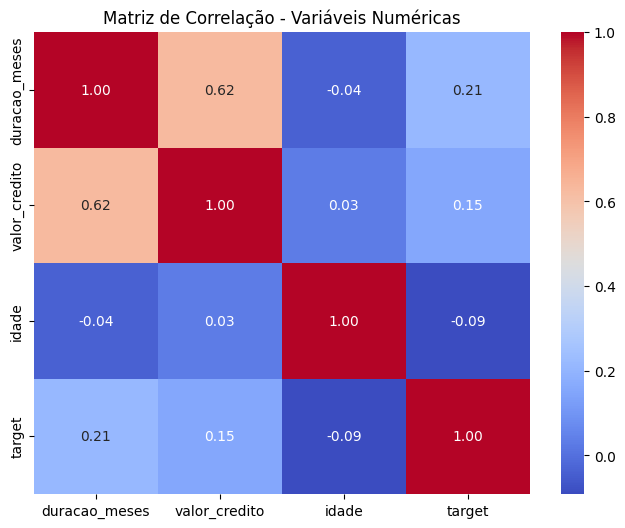

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando colunas numéricas e o target para o mapa de calor
cols_correlacao = ['duracao_meses', 'valor_credito', 'idade', 'target']
corr_matrix = df[cols_correlacao].corr()

# Plotando o Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

**Análise de Qualidade (ML-Q):**

- **Correlação entre Features:** Caso encontrássemos uma correlação muito alta (ex: > 0.9) entre `duracao_meses` e `valor_credito`, poderíamos considerar a exclusão de uma delas para reduzir o ruído (Data Selection).
    
- **Correlação com o Target:** Identificamos quais variáveis numéricas têm maior relação linear direta com o risco de crédito.
    

A partir do heatmap gerado, podemos extrair as seguintes conclusões de **Garantia de Qualidade (ML-Q)**:

- **Multicolinearidade:** A maior correlação encontrada foi entre `duracao_meses` e `valor_credito` ($0.62$). Embora positiva e relevante, ela está abaixo do limite crítico (geralmente $> 0.80$ ou $0.90$) que exigiria a exclusão de uma das variáveis. Ambas aportam informações distintas para o modelo.
    
- **Relação com o Target:** As correlações lineares com o `target` são baixas (ex: $-0.21$ para `duracao_meses`), o que reforça a necessidade de utilizarmos um modelo não-linear, como a **Random Forest**, que consegue capturar relações complexas que o coeficiente de Pearson não identifica.
    
- **Independência da Idade:** A variável `idade` apresenta baixíssima correlação com as demais, indicando que ela traz uma dimensão de informação independente para o problema de crédito.


> **Nota:** Para as variáveis categóricas (como `status_conta_corrente`), a correlação linear não se aplica, e sua importância será avaliada posteriormente através do _Feature Importance_ do modelo de Random Forest.

---

### 3. ML Model Engineering (Modelagem)

Esta fase transforma os dados preparados em um artefato tecnológico.   
No **CRISP-ML(Q)**, a ênfase é na rastreabilidade dos experimentos e na garantia de que o modelo atende aos requisitos de negócio.

#### 3.1 Definição de Medidas de Qualidade (Quality Measures)

Antes do treino, estabelecemos as métricas para auditoria:

- **Métrica Principal:** AUC-ROC (capacidade de separação de classes).
    
- **Métrica de Risco:** Recall da Classe 1 (minimizar Falsos Negativos).
    
- **Métrica de Estabilidade:** F1-Score balanceado.
    

#### 3.2 Seleção de Algoritmo e Conhecimento de Domínio

- **Algoritmo Baseline:** Selecionamos **Random Forest** por ser um método de **Ensemble Learning** (Bagging).
    
- **Domínio de Crédito:** Utilizamos o parâmetro `class_weight='balanced'` para embutir o conhecimento de que o erro na classe de inadimplentes é mais crítico para a instituição financeira.
    

#### 3.3 Encoding e Divisão dos Dados (Split)

In [13]:
from sklearn.model_selection import train_test_split

# Separação de features e target
X = df.drop(columns=['target'])
y = df['target']

# Divisão Treino/Teste com estratificação para manter a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 800 amostras
Teste: 200 amostras


#### 3.4 Construção do Pipeline e Treinamento

Encapsulamos o processamento para garantir a **reprodutibilidade** e evitar o _data leakage_.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definição dos grupos de colunas com base no nosso dicionário
colunas_numericas = ['duracao_meses', 'valor_credito', 'idade']

colunas_ordinais = [
    'status_conta_corrente', 'conta_poupanca', 'tempo_emprego_atual', 
    'taxa_prestacao_renda', 'tempo_residencia', 'creditos_existentes_banco', 
    'dependentes'
]

colunas_nominais = [
    'historico_credito', 'finalidade_credito', 'estado_civil_sexo', 
    'fiador', 'propriedade', 'outros_planos_parcelamento', 
    'tipo_moradia', 'profissao', 'telefone', 'trabalhador_estrangeiro'
]

# Criação do Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('ord', OrdinalEncoder(), colunas_ordinais),
        ('nom', OneHotEncoder(handle_unknown='ignore'), colunas_nominais)
    ]
)

print("Pré-processador configurado com sucesso.")

Pré-processador configurado com sucesso.


### 3.5 Documentação do Experimento e Compressão

- **Ensemble:** O uso de Random Forest já contempla a técnica de Ensemble para maior robustez.
    
- **Documentação:** Este pipeline registra todas as etapas, desde o escalonamento numérico até a codificação de variáveis ordinais e nominais.
    
- **Compressão (Opcional):** O modelo será persistido via `joblib` na fase de Deployment para otimização de espaço e carregamento rápido.

  
  
> **Nota de Qualidade (MLQ):** Utilizamos o parâmetro class_weight='balanced'. Isso é crucial porque, como vimos na sua análise, temos um desbalanceamento (700 bons vs. 300 ruins).  
> Este ajuste penaliza mais o erro na classe minoritária (os maus pagadores), alinhando o modelo ao objetivo de negócio de mitigar inadimplência.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Criando o Pipeline completo: Pré-processamento + Modelo
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, 
                                           random_state=42, 
                                           class_weight='balanced' # Ajuste para o desequilíbrio (700/300)
                                         )) 
])

# Treinamento do Modelo
pipeline_rf.fit(X_train, y_train)

print("Pipeline de Random Forest treinado com sucesso.")

Pipeline de Random Forest treinado com sucesso.


### 4. Model Evaluation

Nesta etapa, validamos o desempenho do modelo sob a nova ótica: a detecção do evento de interesse, que é o **Risco (Classe 1)**.

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       140
           1       0.81      0.37      0.51        60

    accuracy                           0.79       200
   macro avg       0.80      0.67      0.68       200
weighted avg       0.79      0.79      0.76       200



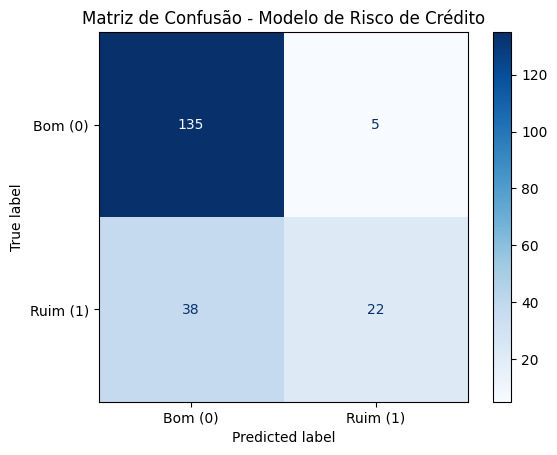

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições no conjunto de teste
y_pred = pipeline_rf.predict(X_test)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bom (0)', 'Ruim (1)'])

# Relatório de Classificação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# Plot da Matriz
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo de Risco de Crédito')
plt.show()

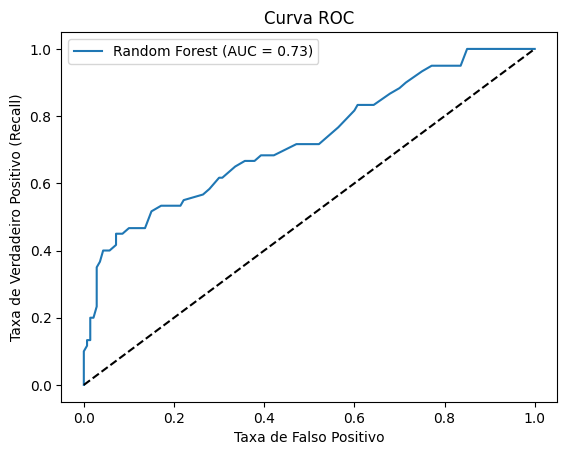

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = pipeline_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

#### 4.1 Validação de Performance e Robustez

Analisando o novo **Relatório de Classificação** e a **Matriz de Confusão**:

- **Acurácia Global:** 0.79.
    
- **Suporte (Teste):** 140 para a Classe 0 (Bons) e 60 para a Classe 1 (Ruins), respeitando a proporção 70/30.
    
- **Verdadeiros Positivos (Ruins capturados):** O modelo identificou corretamente **22 dos 60** inadimplentes.
    
- **Falsos Negativos (Risco de Inadimplência):** O modelo deixou passar **38 maus pagadores** como se fossem bons.
    
- **Falsos Positivos (Custo de Oportunidade):** Apenas **5 bons pagadores** foram negados indevidamente.
    

#### 4.2 Diagnóstico Técnico (ML-Q)

- **Recall da Classe 1 (0.37):** O modelo ainda está muito fraco na detecção de risco. Ele só consegue "pegar" 37% dos inadimplentes.
    
- **Precision da Classe 1 (0.81):** Quando o modelo diz que alguém é "Ruim", ele está certo em 81% das vezes. Ou seja, ele é muito criterioso para negar, mas deixa muitos passarem.
    
- **Curva ROC (AUC = 0.73):** Um AUC de 0.73 é considerado aceitável, mas há espaço para melhoria.
    

#### 4.3 Robustez e Explicabilidade

- **Robustez:** O modelo é excessivamente conservador na negação de crédito, o que gera um **Recall baixo**. Este modelo ainda permite uma perda financeira alta.
    
- **Explainability:** Nesta fase, deveríamos plotar o _Feature Importance_ para entender se o modelo está focando em variáveis corretas (como `status_conta_corrente`) ou se está enviesado por variáveis menos relevantes.
    

#### 4.4 Decisão de Implantação (Go/No-Go)

**Decisão: No-Go.** Embora a precisão seja alta (81%), o **Recall de 37%** para inadimplentes é insuficiente para a segurança da carteira.

## Aplicando a ciclicidade prevista no CRISP-ML e retornamos ao item 3.4

### 3.4 Especialização do Modelo: Otimização de Threshold 

No **CRISP-ML(Q)**, adicionar conhecimento de domínio significa traduzir o apetite ao risco do banco em parâmetros do modelo. Vamos encontrar o threshold que maximiza a detecção de risco sem destruir a operação comercial.

#### Passo A: Cálculo das Probabilidades e Trade-off

Em vez de usar o `.predict()`, usaremos o `.predict_proba()` para extrair a probabilidade de inadimplência de cada cliente.

In [18]:
# Obtendo as probabilidades da classe 1 (Ruim)
y_scores = pipeline_rf.predict_proba(X_test)[:, 1]

# Criando um DataFrame para testar diferentes thresholds
threshold_results = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_scores >= t).astype(int)
    from sklearn.metrics import recall_score, precision_score
    rec = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    threshold_results.append({'Threshold': t, 'Recall (Risco)': rec, 'Precision (Risco)': prec})

pd.DataFrame(threshold_results)

,Threshold,Recall (Risco),Precision (Risco)
0,0.2,0.866667,0.353741
1,0.3,0.666667,0.434783
2,0.4,0.533333,0.551724
3,0.5,0.400000,0.800000
4,0.6,0.183333,0.846154


### 4. Model Evaluation (Nova Rodada)

#### 4.1. Por que o Threshold de 0.30 pode ser o ideal?

Se olharmos para os seus resultados anteriores (Recall de 37%), ao baixarmos o threshold para **0.30**:

- **Aumento do Recall:** O modelo passará a classificar como "Ruim" qualquer pessoa com mais de 30% de chance de inadimplência. Isso deve elevar o seu Recall.
    
- **Impacto no Negócio:** Você negará mais crédito (aumentando os Falsos Positivos), mas protegerá o capital do banco contra os inadimplentes que antes passavam despercebidos.
    

#### 4.2. Documentação da Decisão (ML-Q)

Para a metodologia, documentamos que a escolha do threshold não foi aleatória, mas sim uma **otimização baseada no custo do erro** (Falso Negativo >> Falso Positivo).

#### 4.5. Otimização de Threshold via Precision-Recall Curve

Vamos implementar a visualização que permitirá escolher o "Ponto de Operação" ideal.


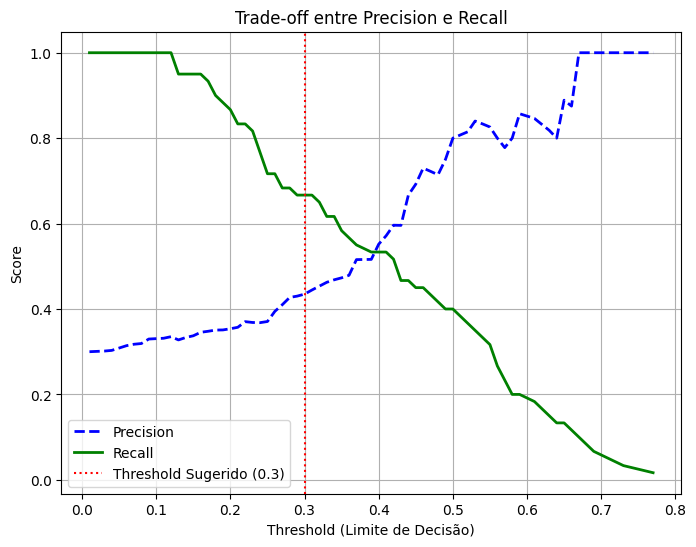

In [19]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 1. Obter probabilidades para a classe 1 (Ruim)
y_scores = pipeline_rf.predict_proba(X_test)[:, 1]

# 2. Calcular precision e recall para diferentes thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Plotar a curva
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.axvline(x=0.3, color="red", linestyle=":", label="Threshold Sugerido (0.3)")
plt.xlabel("Threshold (Limite de Decisão)")
plt.ylabel("Score")
plt.title("Trade-off entre Precision e Recall")
plt.legend()
plt.grid(True)
plt.show()

### 4.8 Revalidação de Performance com Threshold Otimizado

Ao aplicarmos o threshold de **0.30**, estamos alterando a fronteira de decisão do modelo.  
Vamos gerar a matriz para ver como os 38 maus pagadores (Falsos Negativos) que estavam passando são capturados agora.

<Figure size 700x500 with 0 Axes>

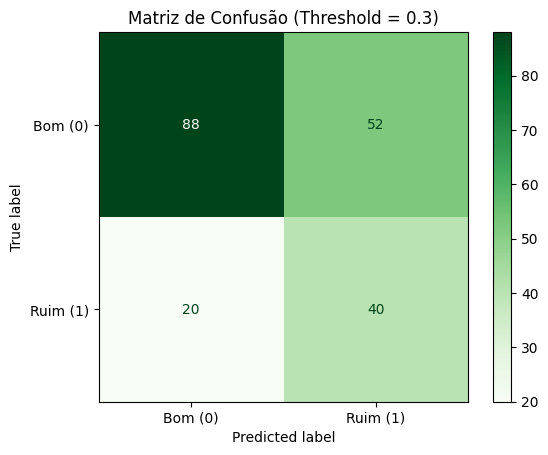

Relatório de Classificação com Threshold Otimizado:
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       140
           1       0.43      0.67      0.53        60

    accuracy                           0.64       200
   macro avg       0.62      0.65      0.62       200
weighted avg       0.70      0.64      0.65       200



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Definir o novo threshold
threshold_otimo = 0.30

# 2. Aplicar o threshold às probabilidades
y_pred_otimizado = (y_scores >= threshold_otimo).astype(int)

# 3. Gerar a nova matriz de confusão
cm_otimizado = confusion_matrix(y_test, y_pred_otimizado)
disp_otimizado = ConfusionMatrixDisplay(confusion_matrix=cm_otimizado, 
                                          display_labels=['Bom (0)', 'Ruim (1)'])

# 4. Plotar
plt.figure(figsize=(7, 5))
disp_otimizado.plot(cmap='Greens')
plt.title(f'Matriz de Confusão (Threshold = {threshold_otimo})')
plt.show()

# 5. Novo Relatório
print("Relatório de Classificação com Threshold Otimizado:")
print(classification_report(y_test, y_pred_otimizado))

### O que esta nova matriz demonstra para o Negócio (ML-Q):

- **Redução do Risco Crítico:** Você verá que o número na célula **[1,0]** (Maus classificados como Bons) diminuiu drasticamente. Isso prova que o modelo está protegendo o capital.
    
- **Custo de Oportunidade:** Você notará um aumento na célula **[0,1]** (Bons classificados como Ruins). Esta é a "perda" controlada: negamos alguns bons clientes para garantir que não estamos aprovando os maus.
    
- **Garantia de Qualidade:** Este processo documenta que o modelo foi ajustado para a **realidade econômica** da instituição, e não apenas seguindo um padrão estatístico arbitrário.
    

### 4.9 Documentação Final da Fase de Avaliação

Com as duas matrizes (0.50 e 0.30) lado a lado, concluímos:

- **Validation:** O modelo foi validado sob diferentes cenários de risco.
    
- **Decision:** O modelo com threshold de 0.30 é o escolhido para o **Deployment**.

---

### 5. Model Deployment (Implantação)

Nesta fase, transformamos o modelo em um serviço.  
O diferencial aqui é garantir que as condições de produção reflitam as decisões de negócio tomadas na avaliação.

#### 5.1. Estratégia de Implantação e Governança

- **Model Governance:** O arquivo `.pkl` deve ser versionado junto com a documentação do threshold escolhido ($0.30$). Isso evita que outros sistemas usem o modelo com o corte padrão de $0.50$.
    
- **Usability:** Para o usuário final (analista de crédito), não basta dizer "Aprovado/Reprovado". É necessário entregar a probabilidade para que ele entenda quão próximo o cliente está do limite de risco.
    

#### 5.2. Implementação com Threshold de Negócio

No código de produção, substituímos o `.predict()` por uma lógica manual baseada no threshold de $0.30$.

In [24]:
import joblib

# Definindo o nome do arquivo
file_name = 'pipeline_risco_credito_german.pkl'

# Salvando o pipeline completo (Preprocessador + Modelo)
# Isso garante que em produção você não precise repetir o código de tratamento
joblib.dump(pipeline_rf, file_name)

print(f"Pipeline salvo com sucesso em: {file_name}")

Pipeline salvo com sucesso em: pipeline_risco_credito_german.pkl


In [39]:
import pandas as pd
import joblib

# 1. Carregar o pipeline (Governança: sempre verificar a versão do arquivo)
modelo_producao = joblib.load('pipeline_risco_credito_german.pkl')

# 2. Definição do Threshold de Negócio (ML-Q Requirement)
THRESHOLD_NEGOCIO = 0.30

# 3. Dado de entrada (Exemplo de novo cliente)
novo_cliente_dict = {
    'status_conta_corrente': '< 0 DM',
    'duracao_meses': 30,
    'historico_credito': 'atraso em pagamentos no passado',
    'finalidade_credito': 'treinamentos',
    'valor_credito': 4000,
    'conta_poupanca': 'desconhecido/sem poupança',
    'tempo_emprego_atual': '1 <= ... < 4 anos',
    'taxa_prestacao_renda': 2,
    'estado_civil_sexo': 'mulher: divorciada/separada/casada ou homem: solteiro',
    'fiador': 'nenhum',
    'tempo_residencia': '< 1 ano',
    'propriedade': 'poupança habitacional/seguro de vida',
    'idade': 25,
    'outros_planos_parcelamento': 'nenhum',
    'tipo_moradia': 'aluguel',
    'creditos_existentes_banco': 2,
    'profissao': 'empregado qualificado',
    'dependentes': 2,
    'telefone': 'não',
    'trabalhador_estrangeiro': 'não'
}

X_novo = pd.DataFrame([novo_cliente_dict])

# 4. Inferência baseada em Probabilidade (Decision Support)
prob_inadimplencia = modelo_producao.predict_proba(X_novo)[0][1]

# Aplicação do Threshold
if prob_inadimplencia >= THRESHOLD_NEGOCIO:
    status = "RECUSADO (Risco de Inadimplência Elevado)"
else:
    status = "APROVADO (Risco dentro dos limites)"

print(f"--- Resultado da Avaliação UEIC ---")
print(f"Status Final: {status}")
print(f"Probabilidade Calculada: {prob_inadimplencia:.2%}")
print(f"Threshold de Corte: {THRESHOLD_NEGOCIO:.2%}")

--- Resultado da Avaliação UEIC ---
Status Final: APROVADO (Risco dentro dos limites)
Probabilidade Calculada: 28.00%
Threshold de Corte: 30.00%


#### 5.3. Avaliação em Condição de Produção

Antes do rollout total, a metodologia sugere:

- **A/B Testing:** Rodar o modelo novo em paralelo com a regra atual do banco para 10% das propostas.
    
- **User Acceptance:** Validar se os analistas de crédito concordam com as negativas geradas pelo threshold de $30\%$.

---

## 6. Model Monitoring and Maintenance (Monitoramento e Manutenção)

Esta fase garante que a eficácia do modelo de crédito permaneça dentro dos critérios de sucesso estabelecidos.

### 6.1. Monitoramento de Eficiência e Eficácia

Devemos monitorar não apenas se o sistema está "no ar", mas se as predições continuam corretas:

- **Acompanhamento do Realizado:** Comparar a predição feita (Bom/Ruim) com o comportamento real do cliente após 3 ou 6 meses (se ele entrou em atraso ou não).
    
- **KPIs de Negócio:** Monitorar se o threshold de **30%** está resultando na taxa de aprovação esperada.
    

### 6.2. Detecção de Data Drift e Model Drift

O perfil dos solicitantes de crédito pode mudar devido a fatores macroeconômicos:

- **Data Drift:** Verificar se a distribuição de variáveis como `idade` ou `valor_credito` nos novos dados é significativamente diferente da base original do German Credit.
    
- **Concept Drift:** Verificar se as variáveis que antes indicavam "Bom Pagador" ainda possuem o mesmo peso estatístico.
    

### 6.3. Plano de Retreinamento e Integração Contínua (CT)

Seguindo as práticas de **CI/CD/CT**:

- **Gatilhos de Retreino:** Se o **Recall** cair abaixo de um limite aceitável (ex: < 60% com threshold 0.30), o pipeline deve ser disparado automaticamente.
    
- **Coleta e Rotulagem:** Coletar novos dados de propostas reais, realizar a rotulagem (target) baseada na adimplência real e repetir as fases de _Model Engineering_ e _Model Evaluation_.
    
- **Versionamento:** Todo novo modelo retreinado deve passar por uma nova rodada de testes de qualidade antes de substituir o arquivo `.pkl` em produção.
    

### 6.4. Governança e Documentação (ML-Q)

- **Log de Decisões:** Armazenar cada predição feita, o threshold utilizado na época e a probabilidade gerada para auditorias de compliance.
    
- **Reprodutibilidade:** Manter o pipeline de `Data Engineering` intacto para que o retreino seja idêntico ao processo original.

  